<a href="https://colab.research.google.com/github/edu-machinelearning/Quantitative-Market-Analysis/blob/main/Quantitative_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Quantitative Market Analysis

Author: Eduardo Moraes - Quantitative, Economist


This project builds a Quant Dashboard with real data for Gold, Oil, US 10Y Yield, and the Dollar Index. It explores correlations, volatility, and short-term forecasts using a VAR(5) model.

Data (2023–2025) from Yahoo Finance is cleaned, analyzed, and visualized through professional charts—ideal for portfolio or executive presentations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
import yfinance as yf

plt.rcParams.update({
'figure.figsize': (12,5),
'axes.titlesize': 14,
'axes.labelsize': 12,
'xtick.labelsize': 10,
'ytick.labelsize': 10,
'legend.fontsize': 10,
'lines.linewidth': 2
})

In [ ]:
tickers = ["GC=F", "CL=F", "^TNX", "DX-Y.NYB"]
data_raw = yf.download(tickers, start="2023-01-01", end="2025-11-11")
if 'Adj Close' in data_raw.columns:
    data = data_raw['Adj Close'].copy()
else:
    data = data_raw['Close'].copy()
data.columns = ["Gold", "Oil", "Tnx", "Dxy"]
data = data.fillna(method='ffill').dropna()
returns = data.pct_change().dropna()

/tmp/ipython-input-2907330479.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(tickers, start="2023-01-01", end="2025-11-11")
[*********************100%***********************]  4 of 4 completed
/tmp/ipython-input-2907330479.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').dropna()


#Correlation Analysis
Quant Report: Correlation identifies co-movement relationships among assets.

 $$\rho_{XY} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}$$

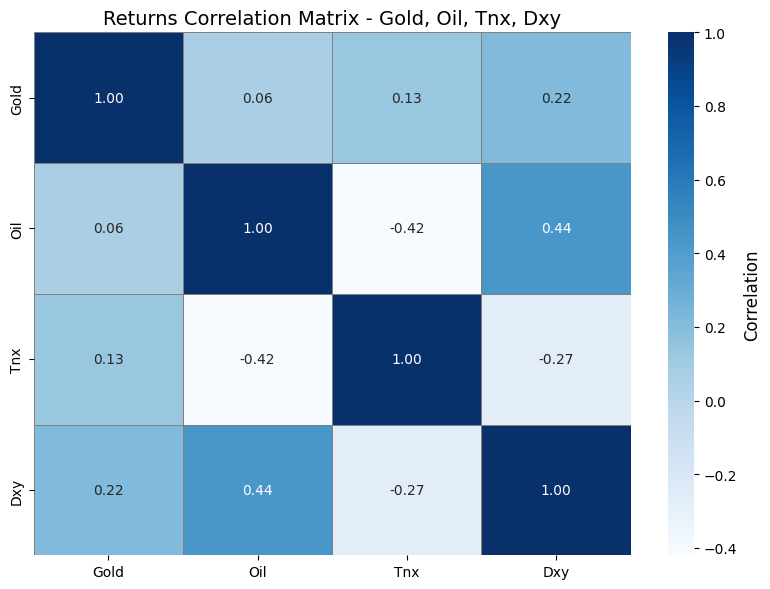

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap='Blues', linewidths=0.7, linecolor='gray', cbar_kws={'label': 'Correlation'})
plt.title('Returns Correlation Matrix - Gold, Oil, Tnx, Dxy')
plt.tight_layout()
plt.show()


#VAR Forecasting
Quant Report: VAR models multivariate interdependencies.

 $$Y_t = c + A_1 Y_{t-1} + ... + A_p Y_{t-p} + \epsilon_t$$

In [ ]:
model = VAR(returns)
lag_order = 5
result = model.fit(lag_order)
forecast_steps = 5
forecast = result.forecast(returns.values[-lag_order:], steps=forecast_steps)
forecast_index = pd.date_range(start=data.index[-1]+pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=data.columns)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



#Price Forecast Visualization
Quant Report: Compare last 60 days actual prices with 5-day forecast.
Cumulative forecast:

 $$P_{t+h} = P_t \prod_{i=1}^{h} (1+R_{t+i})$$

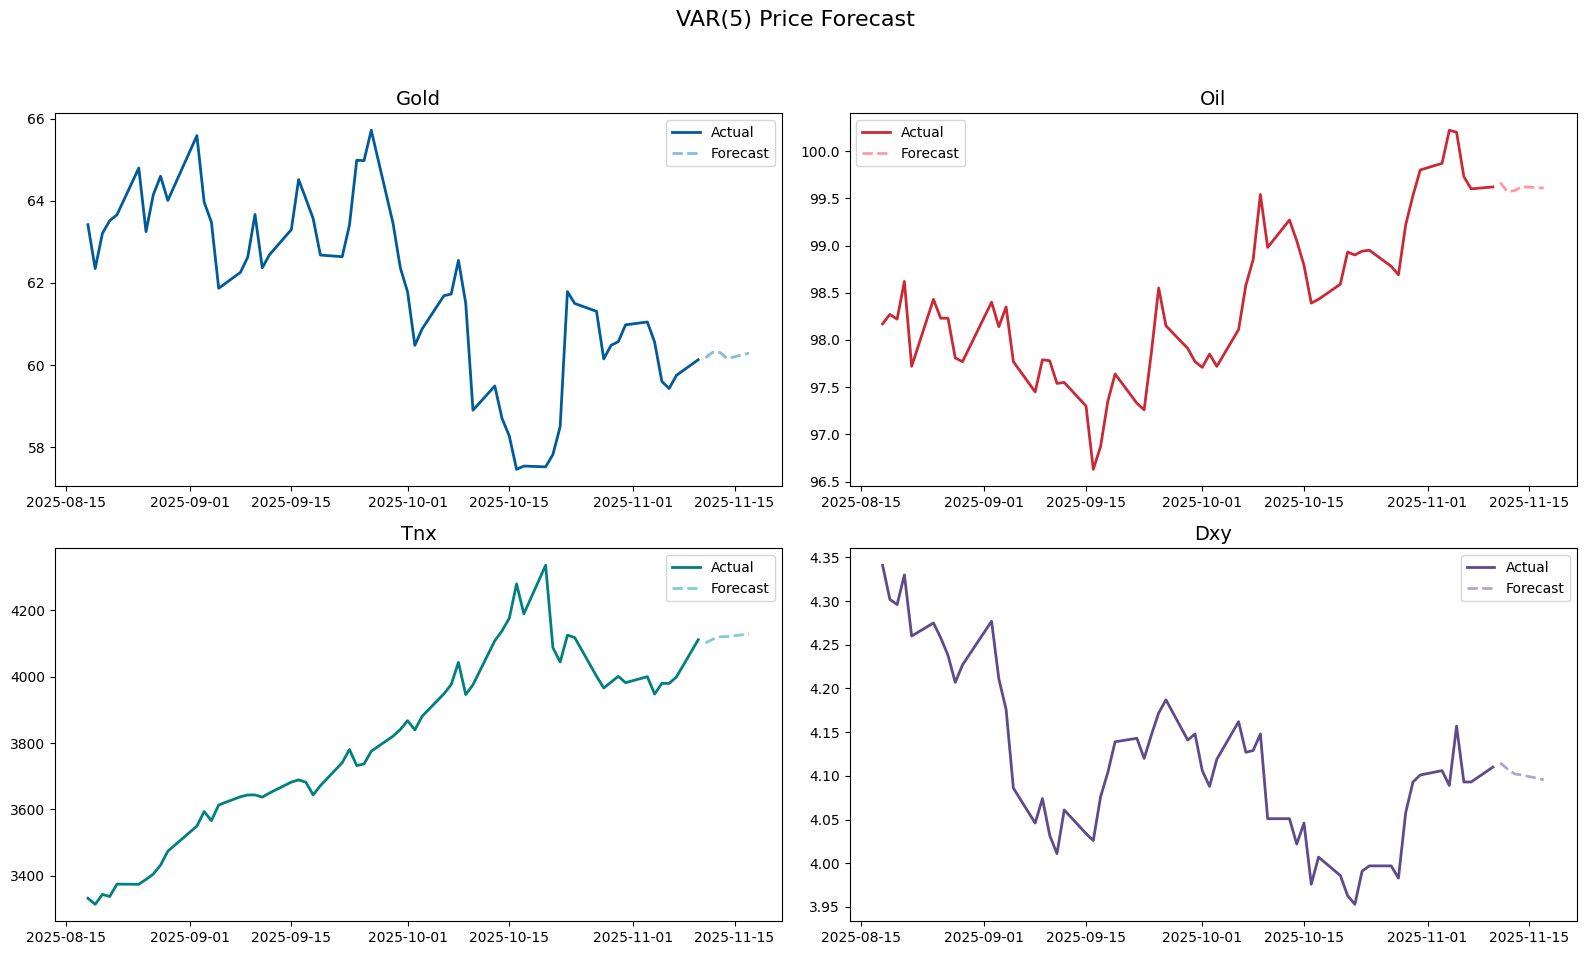

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
colors_actual = ['#005B9A', '#CC2936', '#008080', '#5F4B8B']
colors_forecast = ['#88BBDD', '#FF99A5', '#80CED7', '#B2A6CC']
fig, axes = plt.subplots(2,2, figsize=(16,10))
for i,col in enumerate(data.columns):
    row, col_idx = i//2, i%2
    axes[row,col_idx].plot(data.index[-60:], data[col].tail(60), color=colors_actual[i], label='Actual')
    last = data[col].iloc[-1]
    cumulative = (1+forecast_df[col]).cumprod()
    predicted = [last*x for x in cumulative]
    axes[row,col_idx].plot(forecast_df.index, predicted, color=colors_forecast[i], linestyle='--', label='Forecast')
    axes[row,col_idx].set_title(col)
    axes[row,col_idx].legend()
plt.suptitle('VAR(5) Price Forecast', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


#Historical Volatility
Quant Report: Measures asset risk.

 $$\sigma_t = \sqrt{252} \cdot \text{rolling\_std}(R_t)$$

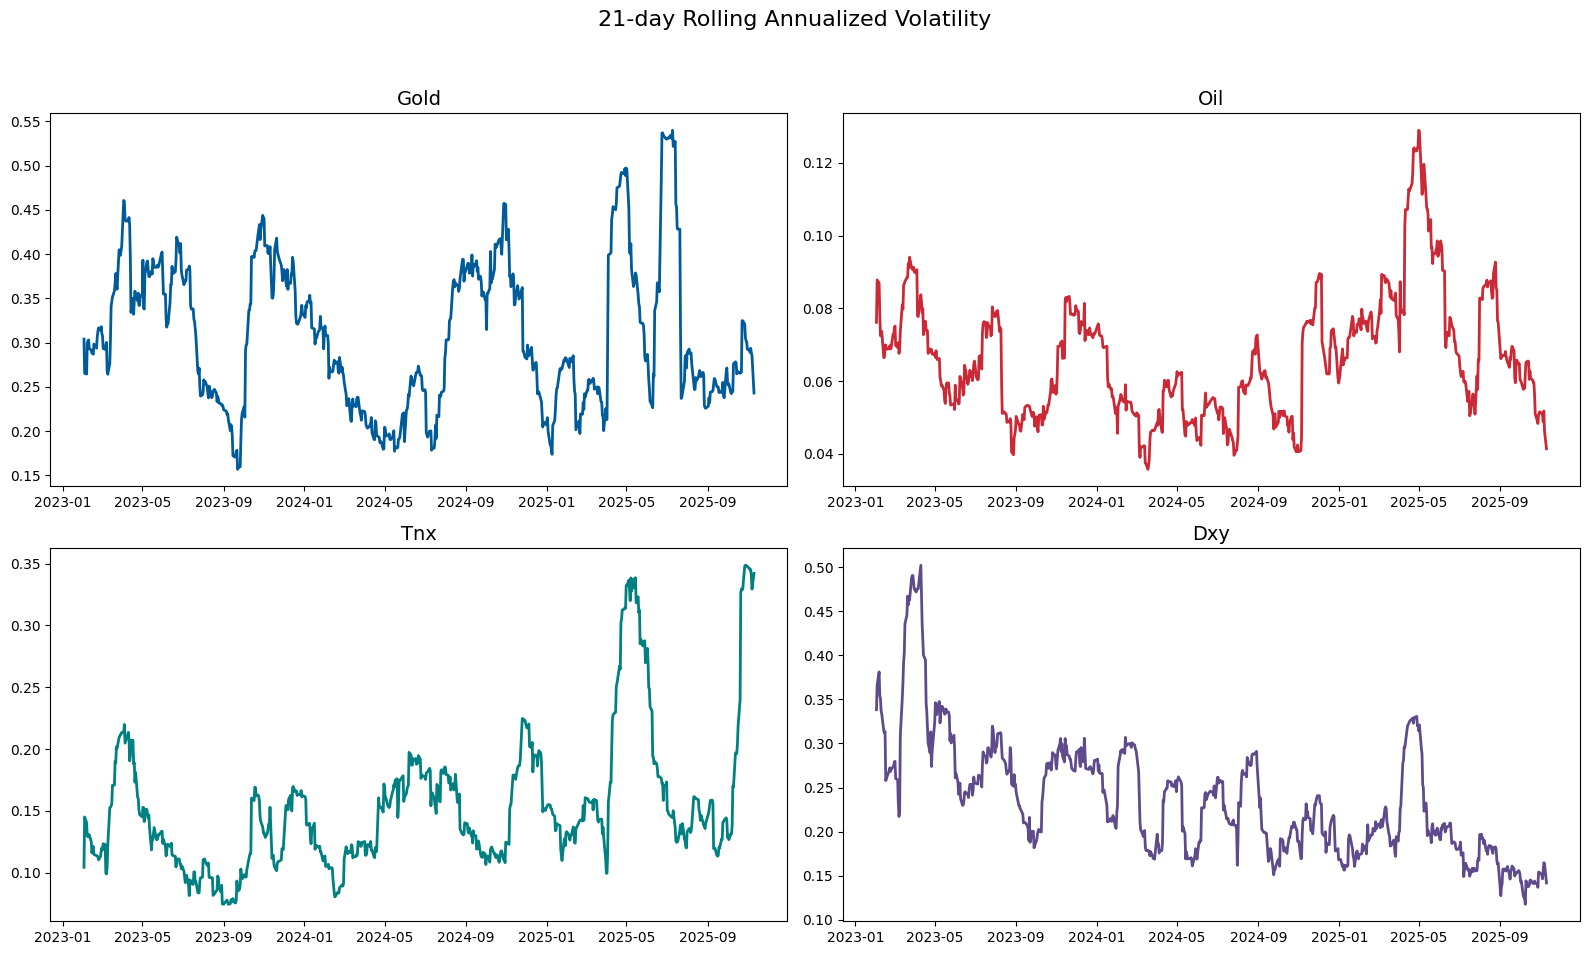

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
colors_actual = ['#005B9A', '#CC2936', '#008080', '#5F4B8B']
window = 21
fig, axes = plt.subplots(2,2, figsize=(16,10))
for i,col in enumerate(returns.columns):
    row,col_idx = i//2,i%2
    rolling_vol = returns[col].rolling(window).std()*np.sqrt(252)
    axes[row,col_idx].plot(rolling_vol, color=colors_actual[i])
    axes[row,col_idx].set_title(col)
plt.suptitle('21-day Rolling Annualized Volatility', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


#Cumulative Returns
Quant Report: Shows total growth over time.

 $$C_t = \prod_{i=1}^{t} (1 + R_i)$$

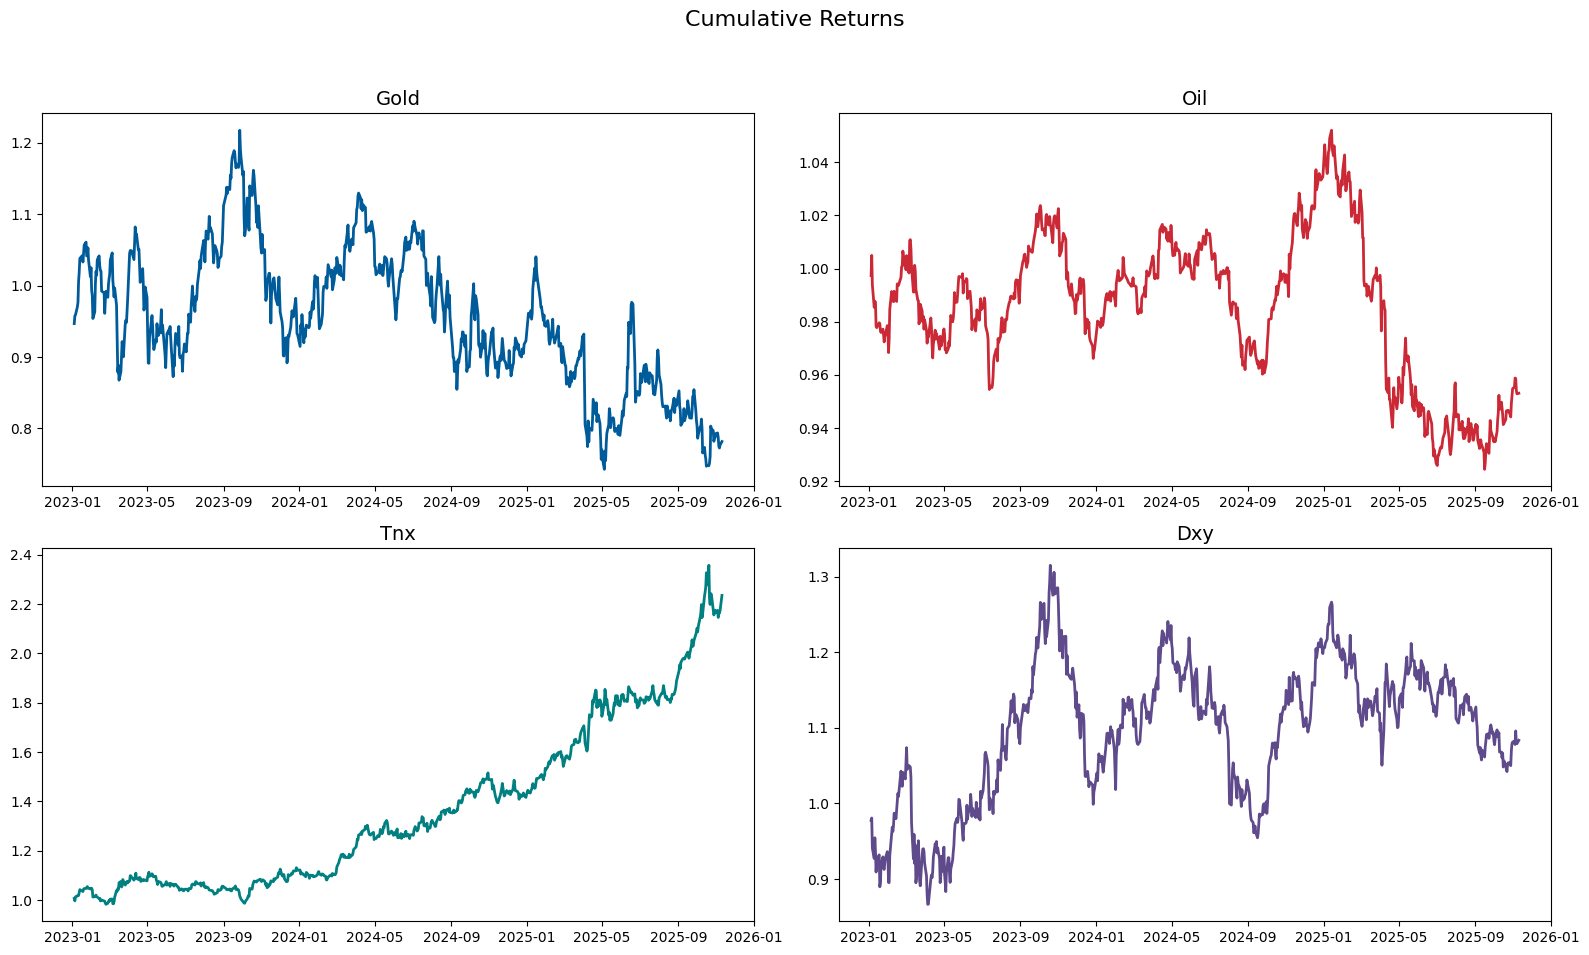

In [ ]:
import matplotlib.pyplot as plt
colors_actual = ['#005B9A', '#CC2936', '#008080', '#5F4B8B']
fig, axes = plt.subplots(2,2, figsize=(16,10))
for i,col in enumerate(returns.columns):
    row,col_idx = i//2,i%2
    cum = (1+returns[col]).cumprod()
    axes[row,col_idx].plot(cum, color=colors_actual[i])
    axes[row,col_idx].set_title(col)
plt.suptitle('Cumulative Returns', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


#Rolling Correlations
Quant Report: 60-day rolling correlations:

 $$\rho_{XY,t} = \text{rolling\_corr}(R_{X,t}, R_{Y,t})$$

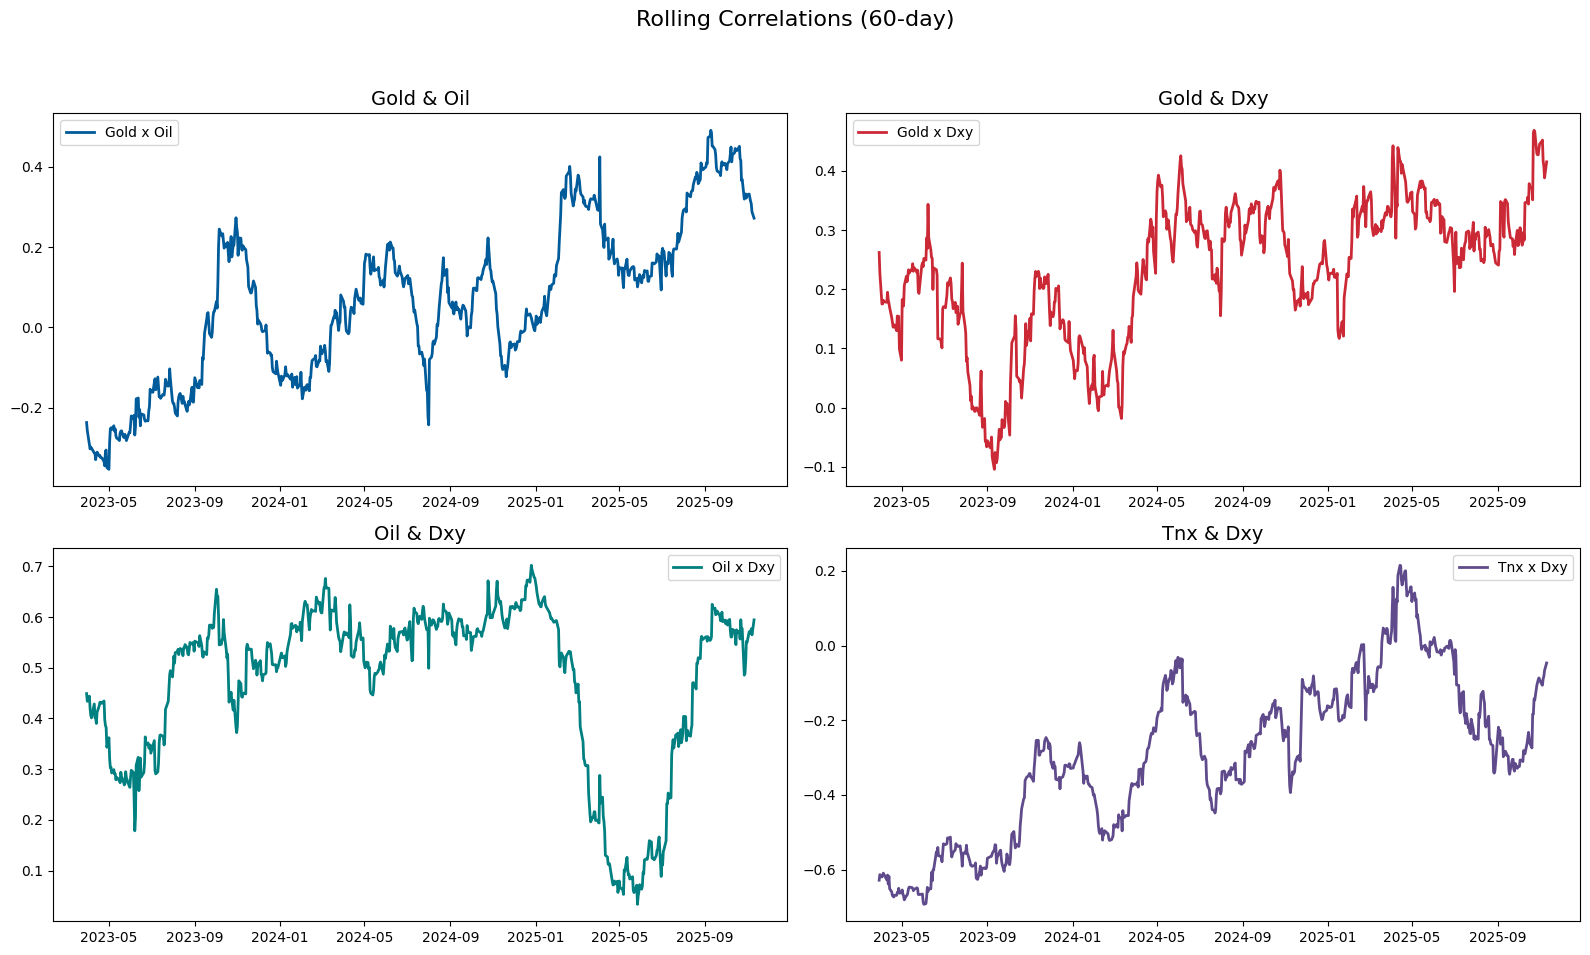

In [ ]:
import matplotlib.pyplot as plt
colors_actual = ['#005B9A', '#CC2936', '#008080', '#5F4B8B']
pairs = [("Gold","Oil"), ("Gold","Dxy"), ("Oil","Dxy"), ("Tnx","Dxy")]
fig, axes = plt.subplots(2,2, figsize=(16,10))
for i,(x,y) in enumerate(pairs):
    row,col_idx = i//2,i%2
    rolling_corr = returns[x].rolling(60).corr(returns[y])
    axes[row,col_idx].plot(rolling_corr, color=colors_actual[i], label=f'{x} x {y}')
    axes[row,col_idx].set_title(f'{x} & {y}')
    axes[row,col_idx].legend()
plt.suptitle('Rolling Correlations (60-day)', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


## Análise de Distribuição

Quant Report: A Análise de Distribuição é crucial para entender o comportamento dos retornos dos ativos. Ela nos permite ir além de apenas a média e a variância, revelando características importantes como a simetria (ou assimetria) e a "caudalidade" (curtose) da distribuição dos retornos.

*Média (Expected Return): Representa o retorno esperado de um ativo. É calculada como:
$$\mu = \frac{1}{n}\sum_{i=1}^{n}R_i$$
onde $R_i$ são os retornos diários e $n$ é o número de observações.

Variância (Risk): Mede a dispersão dos retornos em torno da média, indicando o nível de risco do ativo. É calculada como:
$$\sigma^2 = \frac{1}{n-1}\sum_{i=1}^{n}(R_i - \mu)^2$$
. Ativos com maior variância são considerados mais voláteis.

*   **Assimetria (Skewness)**: Indica o grau de simetria da distribuição dos retornos. Uma assimetria negativa (cauda longa à esquerda) sugere a ocorrência mais frequente de perdas grandes, enquanto uma assimetria positiva (cauda longa à direita) indica a ocorrência de ganhos maiores.

*   **Curtose (Kurtosis)**: Mede a "espessura" das caudas e a "picosidade" da distribuição em comparação com uma distribuição normal. Uma curtose alta (leptocúrtica) indica maior probabilidade de retornos extremos (positivos ou negativos), o que é relevante para a gestão de risco.

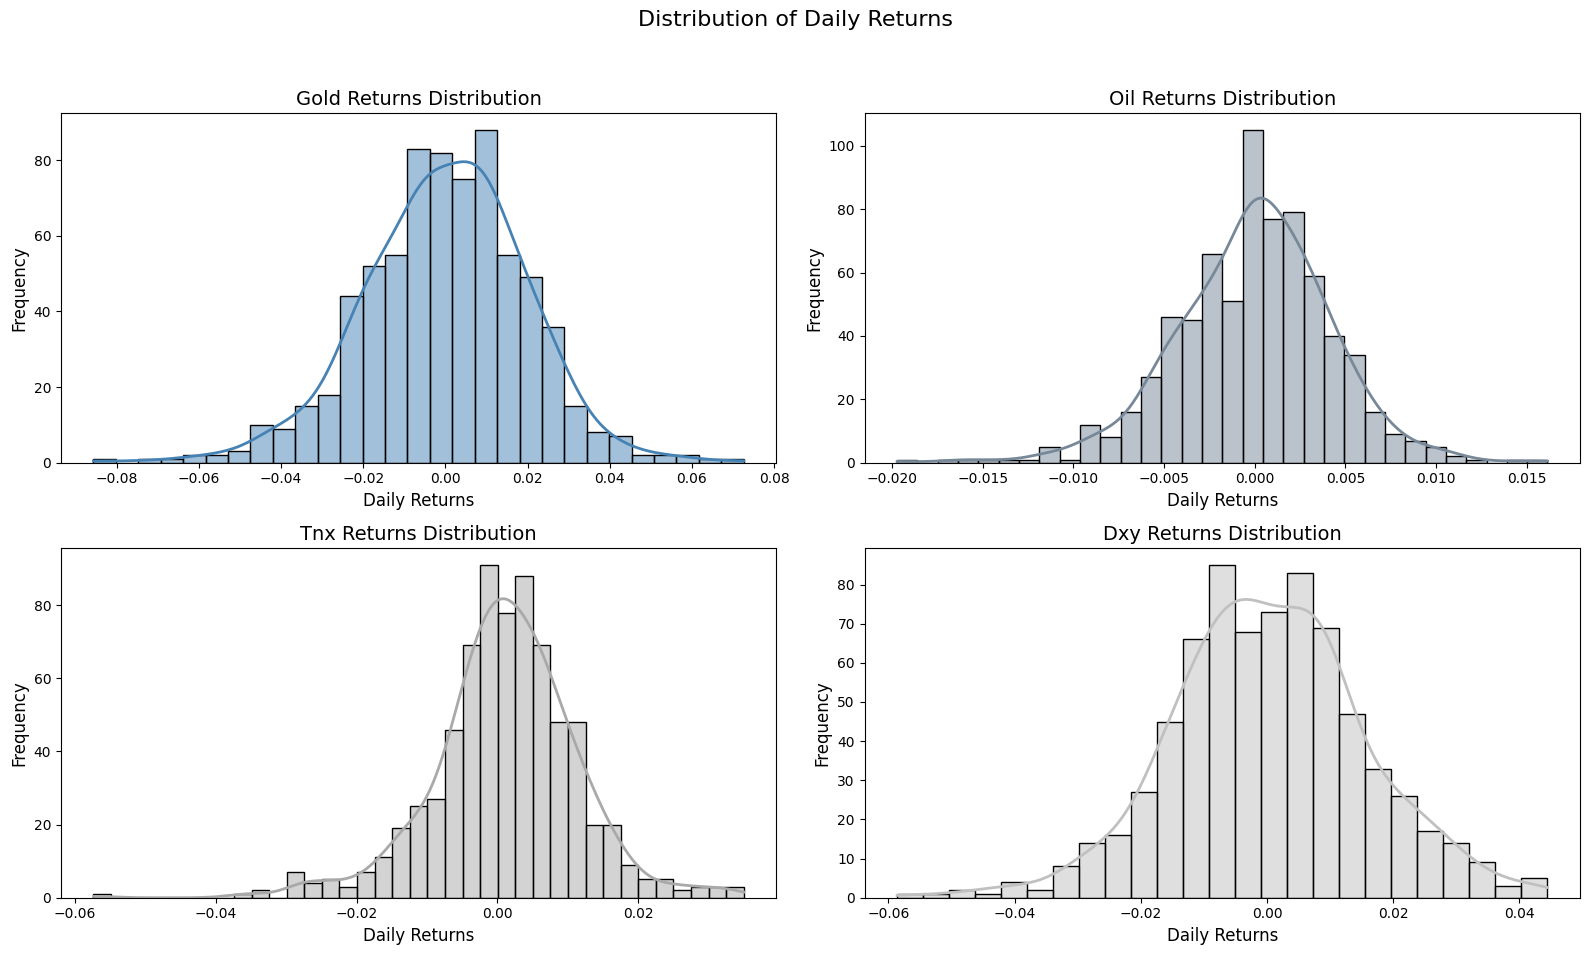

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,2, figsize=(16,10))
colors_hist = ['#4682B4', '#778899', '#A9A9A9', '#C0C0C0']

for i, col in enumerate(returns.columns):
    row, col_idx = i//2, i%2
    sns.histplot(returns[col], kde=True, ax=axes[row,col_idx], color=colors_hist[i])
    axes[row,col_idx].set_title(f'{col} Returns Distribution')
    axes[row,col_idx].set_xlabel('Daily Returns')
    axes[row,col_idx].set_ylabel('Frequency')

plt.suptitle('Distribution of Daily Returns', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

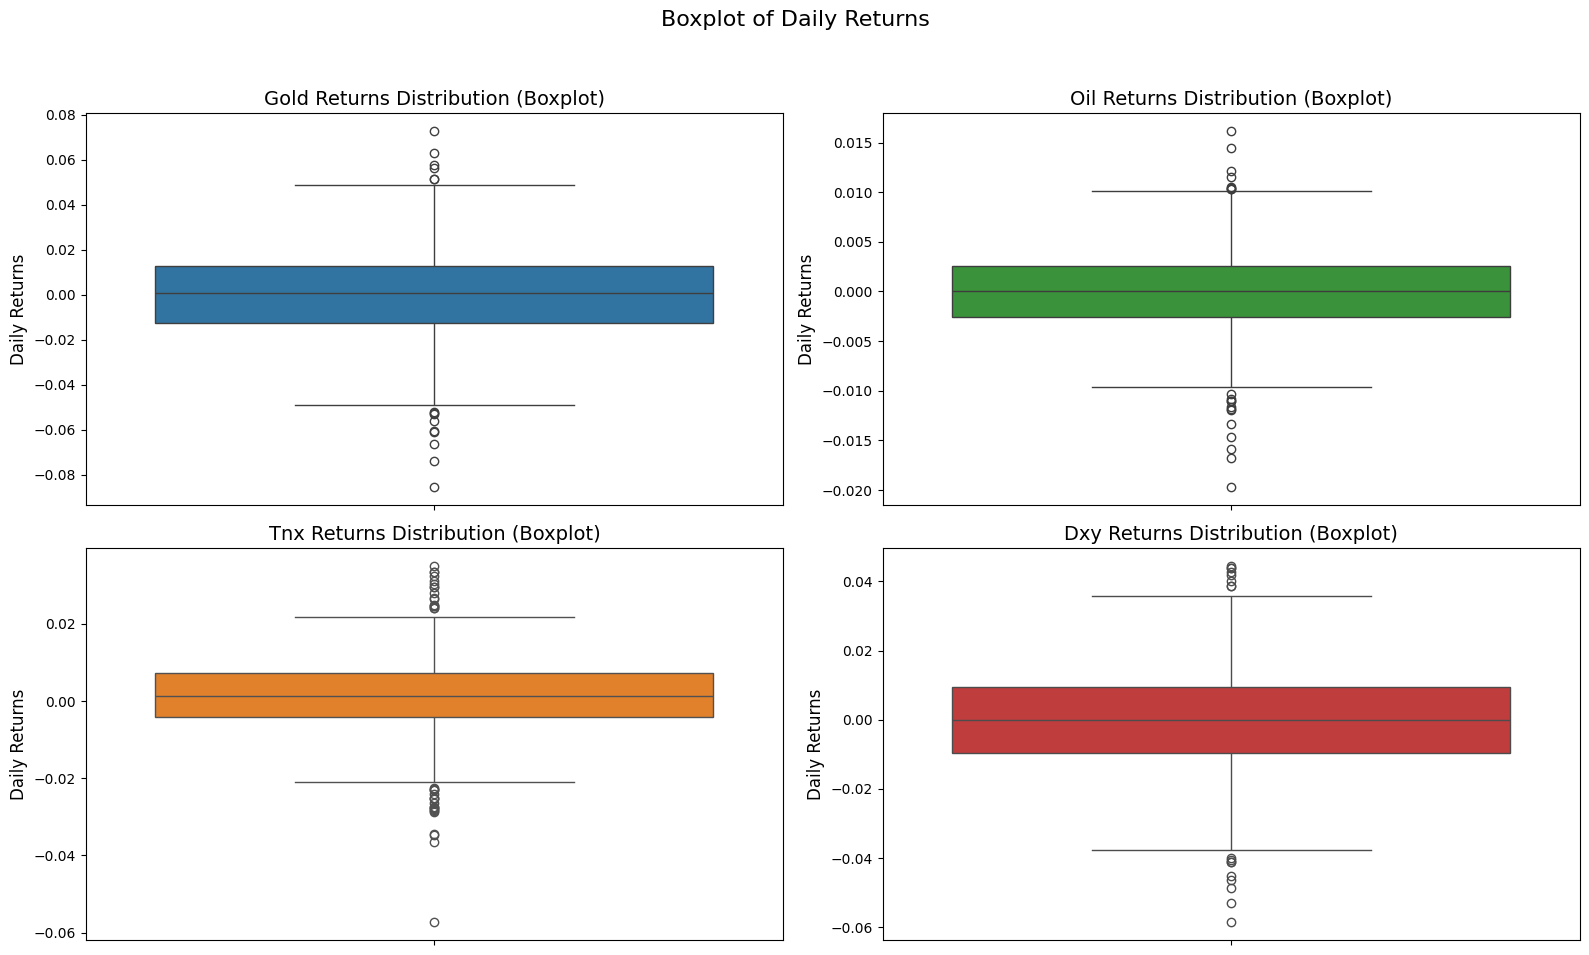

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,2, figsize=(16,10))
colors_box = ['#1F77B4', '#2CA02C', '#FF7F0E', '#D62728']

for i, col in enumerate(returns.columns):
    row, col_idx = i//2, i%2
    sns.boxplot(y=returns[col], ax=axes[row,col_idx], color=colors_box[i])
    axes[row,col_idx].set_title(f'{col} Returns Distribution (Boxplot)')
    axes[row,col_idx].set_ylabel('Daily Returns')

plt.suptitle('Boxplot of Daily Returns', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


## Monthly Seasonality Report

Quant Report: A Análise de Sazonalidade Mensal investiga se os retornos de um ativo exibem padrões consistentes em determinados meses do ano. Entender a sazonalidade pode fornecer insights adicionais sobre o comportamento dos preços e auxiliar em estratégias de investimento de curto a médio prazo.

O retorno médio mensal é calculado como:

$$R_{m} = \frac{1}{N_m}\sum_{i=1}^{N_m}R_{i,m}$$

onde $R_{m}$ é o retorno médio do mês, $N_m$ é o número de observações (retornos diários) no mês $m$, e $R_{i,m}$ são os retornos diários individuais para o mês $m$.


In [ ]:
returns_with_month = returns.copy()
returns_with_month['month'] = returns_with_month.index.month
monthly_avg_returns = returns_with_month.groupby('month')[data.columns].mean()
display(monthly_avg_returns)

,Gold,Oil,Tnx,Dxy
month,,,,
1,0.001694,-0.000082,0.001804,-0.000654
2,-0.000389,0.000497,-0.000767,0.001804
3,0.001218,-0.000788,0.003967,-0.001700
4,-0.003052,-0.000612,0.001713,0.001452
5,-0.001921,0.000155,0.000009,0.001175
6,0.003036,-0.000445,-0.000258,-0.000445
7,0.002656,0.000083,0.001062,0.000262
8,-0.001573,-0.000431,0.001003,-0.000600
9,-0.000169,0.000255,0.001808,0.001104


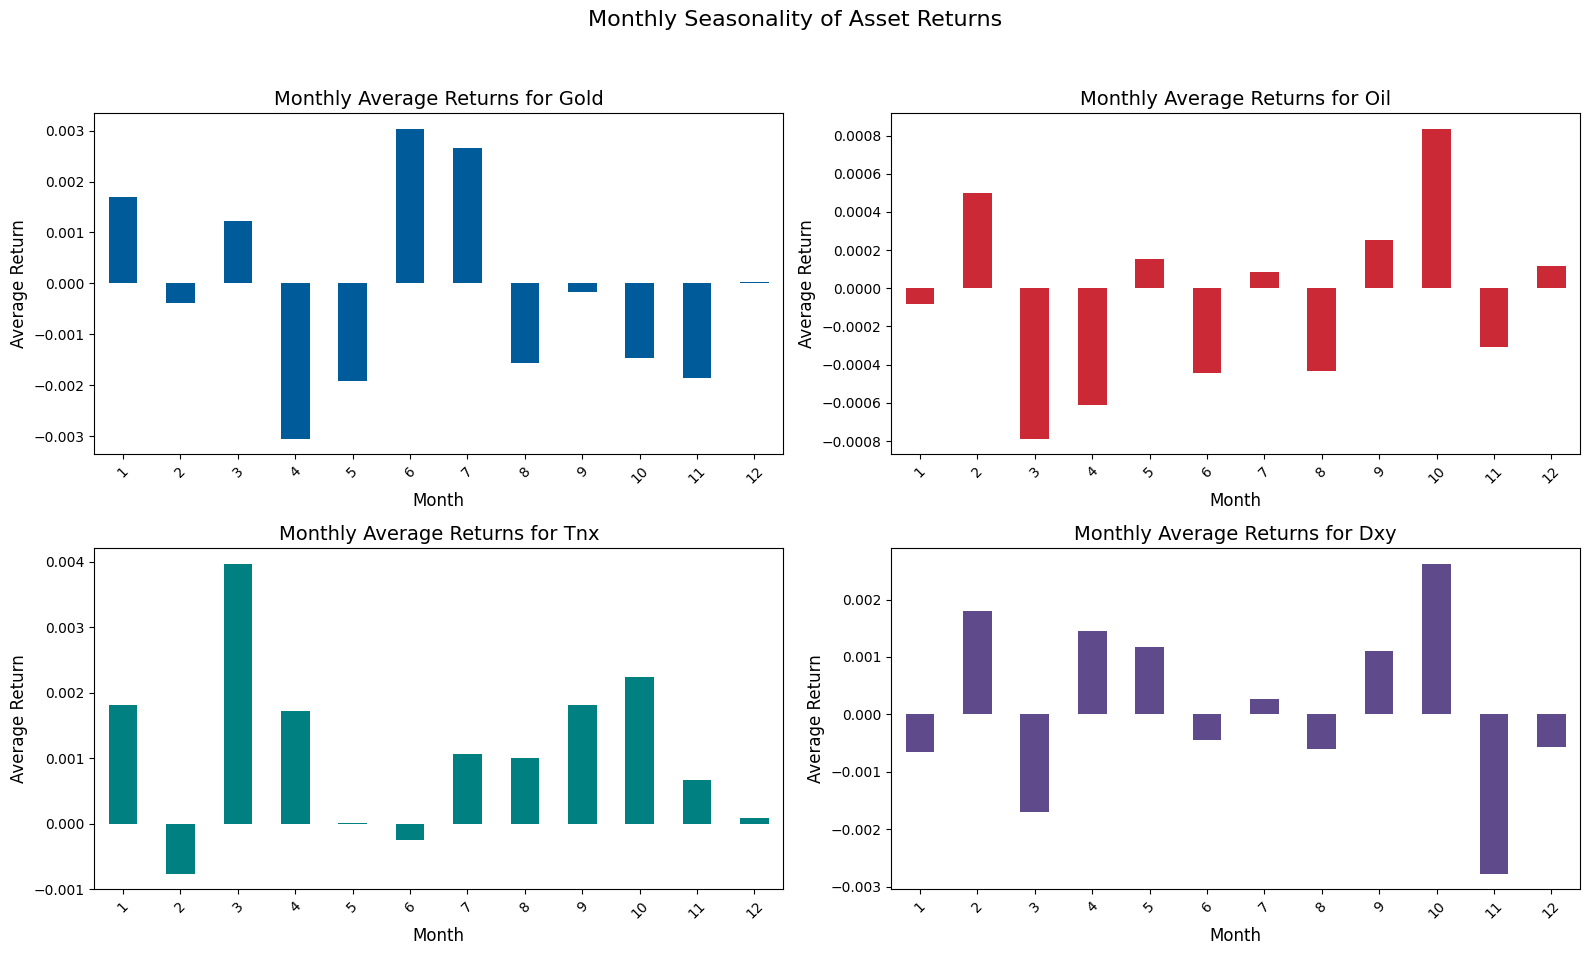

In [ ]:
import matplotlib.pyplot as plt
colors_seasonality = ['#005B9A', '#CC2936', '#008080', '#5F4B8B']
fig, axes = plt.subplots(2,2, figsize=(16,10))

for i, col in enumerate(data.columns):
    row, col_idx = i//2, i%2
    monthly_avg_returns[col].plot(kind='bar', ax=axes[row,col_idx], color=colors_seasonality[i])
    axes[row,col_idx].set_title(f'Monthly Average Returns for {col}')
    axes[row,col_idx].set_xlabel('Month')
    axes[row,col_idx].set_ylabel('Average Return')
    axes[row,col_idx].tick_params(axis='x', rotation=45)

plt.suptitle('Monthly Seasonality of Asset Returns', fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()